## Cleaning the borrowings dataset

In [208]:
# ============================================================================
# UTILITY FUNCTIONS
# Helper functions for displaying missing value summaries and exporting data.
# ============================================================================

def MissingValueSummary(df):
    """
    Display a summary of missing values in a DataFrame.
    
    Shows the total number of instances and a table with:
    - Column names
    - Count of missing values per column
    - Percentage of missing values per column
    
    Args:
        df: pandas DataFrame to analyze
    """
    print(f'Number of instances = {df.shape[0]}')
    print('\nMissing Values Summary:')
    print('=' * 50)

    # Create summary DataFrame with missing value statistics
    missing_data = pd.DataFrame({
        'Column': df.columns,
        'Missing_Values': [df[col].isnull().sum() for col in df.columns],
        'Percent_Missing': [(df[col].isnull().sum() / len(df)) * 100 for col in df.columns]
    })

    # Print formatted table
    print(missing_data.to_string(index=False, formatters={'Percent_Missing': '{:.2f}%'.format}))

In [209]:
import pandas as pd

df = pd.read_csv('../../data/raw/csv/Borrowings.csv', header='infer')
df = df[['Titre','N° lecteur','Catégorie','Date prêt','Date retour']]

# renaming the columns of the dataset
df.columns = ['Title', 'Reader_num', 'category', 'borrowing date', 'return date']
print(f"Number of instances: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.head()

Number of instances: 421
Number of columns: 5


,Title,Reader_num,category,borrowing date,return date
0,Exercices corrigés d'analyse : 1ère année LMD,5817912,1 ére ANNEE,2024-10-15 00:00:00,2024-10-30 00:00:00
1,Exercices d'algèbre et d'analyse : 154 exercic...,5754033,1 ére ANNEE,2024-10-17 00:00:00,2024-11-03 00:00:00
2,Exercices d'algèbre et d'analyse : 154 exercic...,5113394,1 ére ANNEE,2024-10-01 00:00:00,2024-10-16 00:00:00
3,Exercices d'algèbre et d'analyse : 154 exercic...,6092419,1 ére ANNEE,2024-10-15 00:00:00,2024-10-30 00:00:00
4,Exercices et problèmes d'algorithmique : 144 é...,8354464,3 ème ANNEE,2023-10-17 00:00:00,2023-10-24 00:00:00


In [210]:
#calculate the number of missing attributes in each columns
for column in df.columns:
    print(f"Number of missing values in column {column}: {df[column].isnull().sum()}")

df = df.dropna()
print(f"Number of instances: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Convert dates to datetime FIRST
df['borrowing date'] = pd.to_datetime(df['borrowing date'])
df['return date'] = pd.to_datetime(df['return date'])

# Turn titles to uppercase BEFORE modifying dates (so the matching works)
df['Title'] = df['Title'].str.upper()

# Handle the 2 extreme cases with books forgotten to return back to the library in summer (sanity check)
df.loc[df['Title'] == 'REINFORCEMENT LEARNING, AN INTRODUCTION', 'return date'] = pd.to_datetime('2024-11-01')
df.loc[df['Title'] == 'DATABASE SYSTEMS : DESIGN, IMPLEMENTATION, & MANAGEMENT', 'return date'] = pd.to_datetime('2024-11-01')

# Calculate borrowing duration
df['borrowing_duration'] = df['return date'] - df['borrowing date']
df['borrowing_duration'] = df['borrowing_duration'].dt.days
df = df[['Title', 'Reader_num', 'category', 'borrowing_duration', 'borrowing date', 'return date']]

Number of missing values in column Title: 0
Number of missing values in column Reader_num: 0
Number of missing values in column category: 0
Number of missing values in column borrowing date: 0
Number of missing values in column return date: 0
Number of instances: 421
Number of columns: 5


In [211]:
# retriving the different values for the category attribute
print(f"The unique values of the categrory attribute: {df['category'].unique()}")

# counting the number of instances for each value in the category column
print("Number of 1st year instances: %d" % (df['category'] == '1 ére ANNEE').sum())
print("Number of 2nd year instances: %d" % (df['category'] == '2 éme ANNEE').sum())
print("Number of 3rd year instances: %d" % (df['category'] == '3 ème ANNEE').sum())
print("Number of 4th year instances: %d" % (df['category'] == '4 éme ANNEE').sum())
print("Number of teacher instances: %d" % (df['category'] == 'Enseignant').sum())
print("Number of emloyee instances: %d" % (df['category'] == 'Employé').sum())

df['category'] = df['category'].replace('Employé', '1 ére ANNEE')

print(f"The unique values of the categrory attribute: {df['category'].unique()}")

#enumerating the values of the category attribute
df['category'] = df['category'].replace('1 ére ANNEE', 1)
df['category'] = df['category'].replace('2 éme ANNEE', 2)
df['category'] = df['category'].replace('3 ème ANNEE', 3)
df['category'] = df['category'].replace('4 éme ANNEE', 4)
df['category'] = df['category'].replace('Enseignant', 0)

print(f"The unique values of the categrory attribute: {df['category'].unique()}")


# Turning the title instances to uppercase
df['Title'] = df['Title'].str.upper()
df.head(10)

The unique values of the categrory attribute: <StringArray>
['1 ére ANNEE', '3 ème ANNEE',  'Enseignant', '2 éme ANNEE', '4 éme ANNEE',
     'Employé']
Length: 6, dtype: str
Number of 1st year instances: 198
Number of 2nd year instances: 132
Number of 3rd year instances: 49
Number of 4th year instances: 21
Number of teacher instances: 19
Number of emloyee instances: 2
The unique values of the categrory attribute: <StringArray>
['1 ére ANNEE', '3 ème ANNEE', 'Enseignant', '2 éme ANNEE', '4 éme ANNEE']
Length: 5, dtype: str
The unique values of the categrory attribute: [1 3 0 2 4]


,Title,Reader_num,category,borrowing_duration,borrowing date,return date
0,EXERCICES CORRIGÉS D'ANALYSE : 1ÈRE ANNÉE LMD,5817912,1,15,2024-10-15,2024-10-30
1,EXERCICES D'ALGÈBRE ET D'ANALYSE : 154 EXERCIC...,5754033,1,17,2024-10-17,2024-11-03
2,EXERCICES D'ALGÈBRE ET D'ANALYSE : 154 EXERCIC...,5113394,1,15,2024-10-01,2024-10-16
3,EXERCICES D'ALGÈBRE ET D'ANALYSE : 154 EXERCIC...,6092419,1,15,2024-10-15,2024-10-30
4,EXERCICES ET PROBLÈMES D'ALGORITHMIQUE : 144 É...,8354464,3,7,2023-10-17,2023-10-24
5,MATHÉMATIQUES : MÉTHODES ET EXERCICES MP,6747275,3,7,2023-10-17,2023-10-24
6,"MATHÉMATIQUES, EC 1RE ANNÉE : TOUT-EN-UN : COU...",33,0,16,2024-06-27,2024-07-13
7,MATHS PCSI-PTSI,6243736,1,15,2024-10-21,2024-11-05
8,MATHS PCSI-PTSI,5868325,1,15,2024-10-13,2024-10-28
9,MATHS PCSI-PTSI : 1RE ANNÉE,3825689,2,11,2023-10-17,2023-10-28


In [212]:
# calculate how many unique books (by title) have been borrowed
print(f"Total borrowed books: {df['Title'].nunique()}")


# calculate how manu unique borrowers are there
print(f"Total unique borrowers: {df['Reader_num'].nunique()}")

Total borrowed books: 132
Total unique borrowers: 271


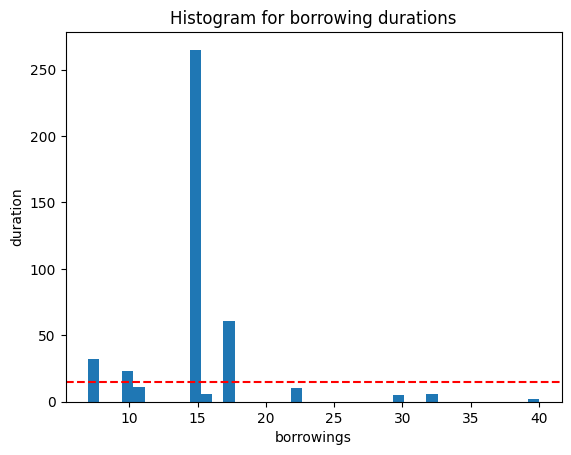

In [213]:
# Visualization EDA
import matplotlib.pyplot as plt

# visualizing the borrowing duration

plt.figure()
plt.hist(df['borrowing_duration'], bins=40)
plt.xlabel("borrowings")
plt.ylabel("duration")
plt.axhline(df['borrowing_duration'].mean(), linestyle='--', color='red')
plt.title("Histogram for borrowing durations")
plt.show()

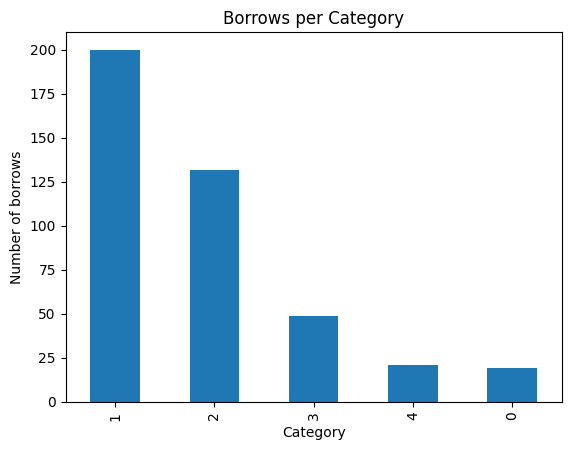

In [214]:
plt.figure()
df['category'].value_counts().plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Number of borrows")
plt.title("Borrows per Category")
plt.show()

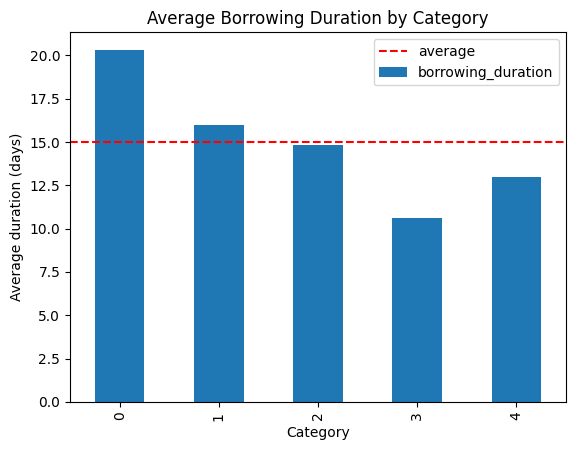

In [215]:
# visualizing the average borrowing duration per category

plt.figure()
df.groupby('category')['borrowing_duration'].mean().plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Average duration (days)")
plt.title("Average Borrowing Duration by Category")
plt.axhline(df['borrowing_duration'].mean(), linestyle='--', color='red', label='average')
plt.legend()
plt.show()


<Figure size 640x480 with 0 Axes>

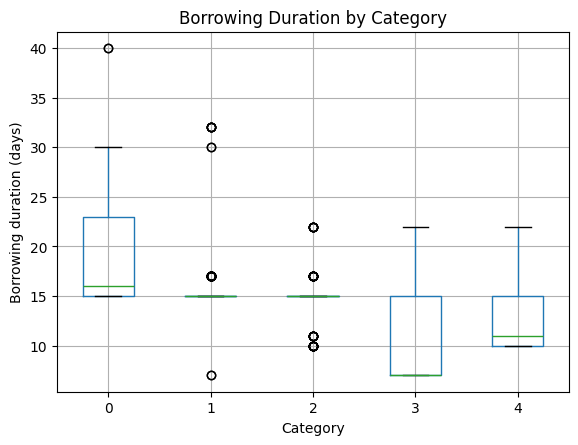

In [216]:
# boxplot (category vs borrowing_duration) for detecting outliers

plt.figure()
df.boxplot(column='borrowing_duration', by='category')
plt.xlabel("Category")
plt.ylabel("Borrowing duration (days)")
plt.title("Borrowing Duration by Category")
plt.suptitle("")
plt.show()

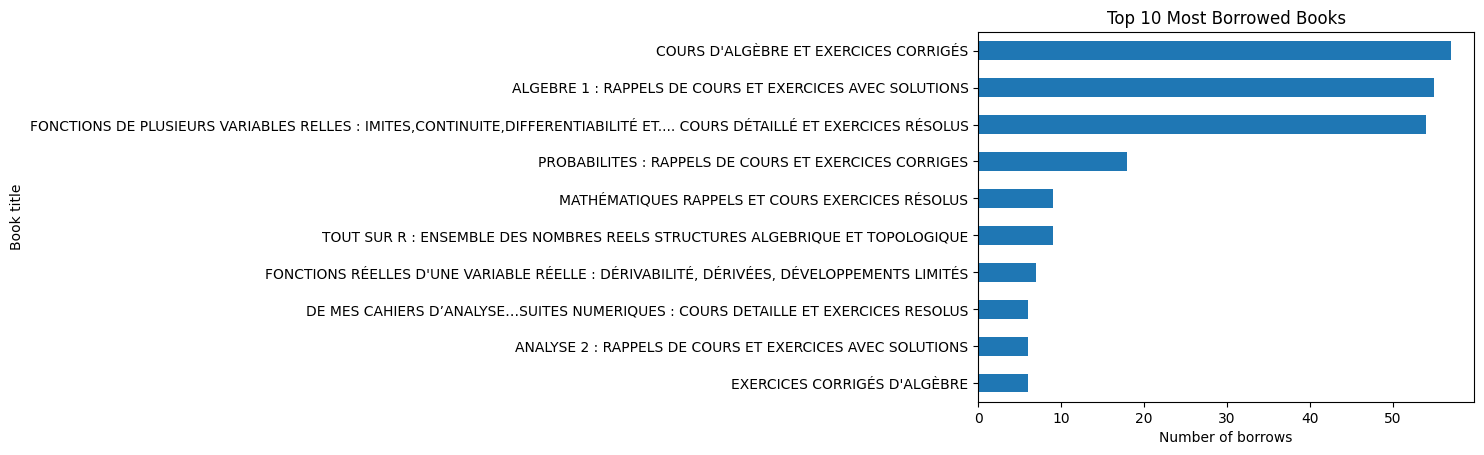

In [217]:
# most borrowed books

plt.figure()
df['Title'].value_counts().head(10).plot(kind='barh')
plt.xlabel("Number of borrows")
plt.ylabel("Book title")
plt.title("Top 10 Most Borrowed Books")
plt.gca().invert_yaxis()
plt.show()

In [218]:
MissingValueSummary(df)

Number of instances = 421

Missing Values Summary:
            Column  Missing_Values Percent_Missing
             Title               0           0.00%
        Reader_num               0           0.00%
          category               0           0.00%
borrowing_duration               0           0.00%
    borrowing date               0           0.00%
       return date               0           0.00%


## Data Distribution Analysis

In [219]:
import numpy as np
from scipy import stats

print("="*70)
print("1. BORROWING DURATION STATISTICS")
print("="*70)
print(f"Mean duration: {df['borrowing_duration'].mean():.2f} days")
print(f"Median duration: {df['borrowing_duration'].median():.2f} days")
print(f"Mode duration: {df['borrowing_duration'].mode().values[0]:.0f} days")
print(f"Std deviation: {df['borrowing_duration'].std():.2f} days")
print(f"Min duration: {df['borrowing_duration'].min():.0f} days")
print(f"Max duration: {df['borrowing_duration'].max():.0f} days")
print(f"Q1 (25th percentile): {df['borrowing_duration'].quantile(0.25):.2f} days")
print(f"Q3 (75th percentile): {df['borrowing_duration'].quantile(0.75):.2f} days")
print(f"IQR: {df['borrowing_duration'].quantile(0.75) - df['borrowing_duration'].quantile(0.25):.2f} days")
print(f"Skewness: {stats.skew(df['borrowing_duration']):.3f}")
print(f"Kurtosis: {stats.kurtosis(df['borrowing_duration']):.3f}")

1. BORROWING DURATION STATISTICS
Mean duration: 15.02 days
Median duration: 15.00 days
Mode duration: 15 days
Std deviation: 4.27 days
Min duration: 7 days
Max duration: 40 days
Q1 (25th percentile): 15.00 days
Q3 (75th percentile): 15.00 days
IQR: 0.00 days
Skewness: 1.872
Kurtosis: 9.258


In [220]:
print("="*70)
print("2. CATEGORY DISTRIBUTION")
print("="*70)
category_counts = df['category'].value_counts().sort_index()
category_labels = {0: 'Teacher', 1: '1st Year', 2: '2nd Year', 3: '3rd Year', 4: '4th Year'}
for cat_num, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Category {category_labels[cat_num]}: {count} ({percentage:.2f}%)")

2. CATEGORY DISTRIBUTION
Category Teacher: 19 (4.51%)
Category 1st Year: 200 (47.51%)
Category 2nd Year: 132 (31.35%)
Category 3rd Year: 49 (11.64%)
Category 4th Year: 21 (4.99%)


In [221]:
print("="*70)
print("3. BORROWING DURATION BY CATEGORY")
print("="*70)
for cat_num in sorted(df['category'].unique()):
    cat_data = df[df['category'] == cat_num]['borrowing_duration']
    print(f"\n{category_labels[cat_num]}:")
    print(f"  Mean: {cat_data.mean():.2f} days")
    print(f"  Median: {cat_data.median():.2f} days")
    print(f"  Std Dev: {cat_data.std():.2f} days")
    print(f"  Min/Max: {cat_data.min():.0f}/{cat_data.max():.0f} days")

3. BORROWING DURATION BY CATEGORY

Teacher:
  Mean: 20.32 days
  Median: 16.00 days
  Std Dev: 8.80 days
  Min/Max: 15/40 days

1st Year:
  Mean: 15.97 days
  Median: 15.00 days
  Std Dev: 3.38 days
  Min/Max: 7/32 days

2nd Year:
  Mean: 14.80 days
  Median: 15.00 days
  Std Dev: 2.61 days
  Min/Max: 10/22 days

3rd Year:
  Mean: 10.59 days
  Median: 7.00 days
  Std Dev: 4.76 days
  Min/Max: 7/22 days

4th Year:
  Mean: 13.00 days
  Median: 11.00 days
  Std Dev: 3.39 days
  Min/Max: 10/22 days


In [222]:
print("="*70)
print("4. READER BORROWING PATTERNS")
print("="*70)
reader_borrows = df['Reader_num'].value_counts()
print(f"Total unique readers: {len(reader_borrows)}")
print(f"Average borrows per reader: {reader_borrows.mean():.2f}")
print(f"Median borrows per reader: {reader_borrows.median():.0f}")
print(f"Most active reader borrowed: {reader_borrows.max()} times")
print(f"Reader distribution (top 5):")
for reader, count in reader_borrows.head().items():
    print(f"  Reader {reader}: {count} borrows")

4. READER BORROWING PATTERNS
Total unique readers: 271
Average borrows per reader: 1.55
Median borrows per reader: 1
Most active reader borrowed: 3 times
Reader distribution (top 5):
  Reader 5817912: 3 borrows
  Reader 5754033: 3 borrows
  Reader 33: 3 borrows
  Reader 6243736: 3 borrows
  Reader 5868325: 3 borrows


In [223]:
print("="*70)
print("5. BOOK POPULARITY DISTRIBUTION")
print("="*70)
book_borrows = df['Title'].value_counts()
print(f"Total unique books borrowed: {len(book_borrows)}")
print(f"Average borrows per book: {book_borrows.mean():.2f}")
print(f"Median borrows per book: {book_borrows.median():.0f}")
print(f"Most borrowed book: {book_borrows.max()} times")
print(f"Books with single borrow: {(book_borrows == 1).sum()}")
print(f"Books with 5+ borrows: {(book_borrows >= 5).sum()}")

5. BOOK POPULARITY DISTRIBUTION
Total unique books borrowed: 132
Average borrows per book: 3.19
Median borrows per book: 1
Most borrowed book: 57 times
Books with single borrow: 84
Books with 5+ borrows: 15


In [224]:
print("="*70)
print("6. OUTLIER ANALYSIS (IQR Method)")
print("="*70)
Q1 = df['borrowing_duration'].quantile(0.25)
Q3 = df['borrowing_duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['borrowing_duration'] < lower_bound) | (df['borrowing_duration'] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f} days")
print(f"Upper bound: {upper_bound:.2f} days")
print(f"Number of outliers: {len(outliers)} ({(len(outliers)/len(df))*100:.2f}%)")

6. OUTLIER ANALYSIS (IQR Method)
Lower bound: 15.00 days
Upper bound: 15.00 days
Number of outliers: 156 (37.05%)


In [225]:
print("="*70)
print("7. KEY INSIGHTS")
print("="*70)
print(f"✓ Most borrowings are short-term (median: {df['borrowing_duration'].median():.0f} days)")
print(f"✓ Skewness: {stats.skew(df['borrowing_duration']):.3f} - Distribution is {'right-skewed (longer tail)' if stats.skew(df['borrowing_duration']) > 0.5 else 'relatively symmetric'}")
print(f"✓ {(book_borrows == 1).sum()} unique books borrowed only once - indicates diverse collection")
print(f"✓ Reader engagement varies significantly (std dev of borrows: {reader_borrows.std():.2f})")
print(f"✓ {len(outliers)} extreme cases ({(len(outliers)/len(df))*100:.2f}%) suggest late returns")
print("="*70)

7. KEY INSIGHTS
✓ Most borrowings are short-term (median: 15 days)
✓ Skewness: 1.872 - Distribution is right-skewed (longer tail)
✓ 84 unique books borrowed only once - indicates diverse collection
✓ Reader engagement varies significantly (std dev of borrows: 0.69)
✓ 156 extreme cases (37.05%) suggest late returns


## Probability Distribution Analysis

In [226]:
from scipy.stats import shapiro, normaltest, anderson, kstest, jarque_bera
import matplotlib.pyplot as plt

duration_data = df['borrowing_duration'].values

print("="*70)
print("8. NORMALITY TESTS FOR BORROWING DURATION")
print("="*70)

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = shapiro(duration_data)
print(f"\nShapiro-Wilk Test:")
print(f"  Test Statistic: {shapiro_stat:.6f}")
print(f"  P-value: {shapiro_p:.10f}")
print(f"  Result: {'NORMAL distribution (p > 0.05)' if shapiro_p > 0.05 else 'NOT NORMAL (p < 0.05)'}")

# D'Agostino and Pearson's Test
dagostino_stat, dagostino_p = normaltest(duration_data)
print(f"\nD'Agostino-Pearson Test:")
print(f"  Test Statistic: {dagostino_stat:.6f}")
print(f"  P-value: {dagostino_p:.10f}")
print(f"  Result: {'NORMAL distribution (p > 0.05)' if dagostino_p > 0.05 else 'NOT NORMAL (p < 0.05)'}")

# Anderson-Darling Test
anderson_result = anderson(duration_data)
print(f"\nAnderson-Darling Test:")
print(f"  Test Statistic: {anderson_result.statistic:.6f}")
print(f"  Critical Values: {anderson_result.critical_values}")
print(f"  Significance Levels: {anderson_result.significance_level}%")
print(f"  Result: {'Likely NORMAL' if anderson_result.statistic < anderson_result.critical_values[2] else 'Likely NOT NORMAL'}")

# Jarque-Bera Test
jb_stat, jb_p = jarque_bera(duration_data)
print(f"\nJarque-Bera Test:")
print(f"  Test Statistic: {jb_stat:.6f}")
print(f"  P-value: {jb_p:.10f}")
print(f"  Result: {'NORMAL distribution (p > 0.05)' if jb_p > 0.05 else 'NOT NORMAL (p < 0.05)'}")

8. NORMALITY TESTS FOR BORROWING DURATION

Shapiro-Wilk Test:
  Test Statistic: 0.669565
  P-value: 0.0000000000
  Result: NOT NORMAL (p < 0.05)

D'Agostino-Pearson Test:
  Test Statistic: 203.546476
  P-value: 0.0000000000
  Result: NOT NORMAL (p < 0.05)

Anderson-Darling Test:
  Test Statistic: 54.555382
  Critical Values: [0.56  0.63  0.751 0.871 1.033]
  Significance Levels: [15.  10.   5.   2.5  1. ]%
  Result: Likely NOT NORMAL

Jarque-Bera Test:
  Test Statistic: 1749.314685
  P-value: 0.0000000000
  Result: NOT NORMAL (p < 0.05)


C:\Users\mustapha\AppData\Local\Temp\ipykernel_17724\1392247540.py:25: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  anderson_result = anderson(duration_data)


In [227]:
from scipy.stats import norm, expon, gamma, lognorm, beta

print("="*70)
print("9. DISTRIBUTION FITTING")
print("="*70)

# Fit Normal Distribution
mu, sigma = norm.fit(duration_data)
print(f"\nNormal Distribution Fit:")
print(f"  Mean (μ): {mu:.4f}")
print(f"  Std Dev (σ): {sigma:.4f}")

# Fit Exponential Distribution
lambda_param = expon.fit(duration_data)[1]
print(f"\nExponential Distribution Fit:")
print(f"  Lambda (λ): {1/lambda_param:.6f}")

# Fit Gamma Distribution
gamma_shape, gamma_loc, gamma_scale = gamma.fit(duration_data)
print(f"\nGamma Distribution Fit:")
print(f"  Shape (α): {gamma_shape:.4f}")
print(f"  Scale (β): {gamma_scale:.4f}")
print(f"  Location: {gamma_loc:.4f}")

# Fit Log-Normal Distribution
lognorm_shape, lognorm_loc, lognorm_scale = lognorm.fit(duration_data)
print(f"\nLog-Normal Distribution Fit:")
print(f"  Shape (σ): {lognorm_shape:.4f}")
print(f"  Location: {lognorm_loc:.4f}")
print(f"  Scale (μ): {lognorm_scale:.4f}")

# Fit Beta Distribution
beta_a, beta_b, beta_loc, beta_scale = beta.fit(duration_data)
print(f"\nBeta Distribution Fit:")
print(f"  Alpha (α): {beta_a:.4f}")
print(f"  Beta (β): {beta_b:.4f}")
print(f"  Location: {beta_loc:.4f}")
print(f"  Scale: {beta_scale:.4f}")

9. DISTRIBUTION FITTING

Normal Distribution Fit:
  Mean (μ): 15.0238
  Std Dev (σ): 4.2621

Exponential Distribution Fit:
  Lambda (λ): 0.124630

Gamma Distribution Fit:
  Shape (α): 19.7668
  Scale (β): 0.9149
  Location: -3.0609

Log-Normal Distribution Fit:
  Shape (σ): 0.1674
  Location: -8.9776
  Scale (μ): 23.6603

Beta Distribution Fit:
  Alpha (α): 12.5767
  Beta (β): 2948940.7497
  Location: 0.0485
  Scale: 3518734.5902


c:\Users\mustapha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_continuous_distns.py:806: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\mustapha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_continuous_distns.py:811: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


10. Q-Q PLOT (Quantile-Quantile Plot)
Q-Q Plot shows how well data follows a normal distribution.
Points close to the diagonal line indicate normal distribution.


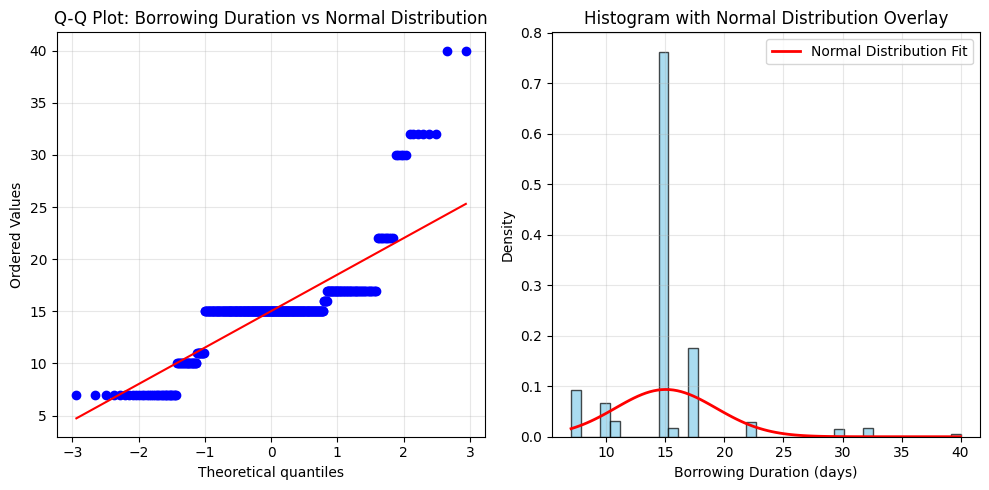

In [228]:
from scipy import stats
import numpy as np

print("="*70)
print("10. Q-Q PLOT (Quantile-Quantile Plot)")
print("="*70)
print("Q-Q Plot shows how well data follows a normal distribution.")
print("Points close to the diagonal line indicate normal distribution.")

plt.figure(figsize=(10, 5))

# Q-Q Plot
plt.subplot(1, 2, 1)
stats.probplot(duration_data, dist="norm", plot=plt)
plt.title("Q-Q Plot: Borrowing Duration vs Normal Distribution")
plt.grid(True, alpha=0.3)

# Histogram with Normal Distribution Overlay
plt.subplot(1, 2, 2)
plt.hist(duration_data, bins=40, density=True, alpha=0.7, color='skyblue', edgecolor='black')
mu, sigma = norm.fit(duration_data)
x = np.linspace(duration_data.min(), duration_data.max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution Fit')
plt.xlabel('Borrowing Duration (days)')
plt.ylabel('Density')
plt.title('Histogram with Normal Distribution Overlay')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [229]:
from scipy.stats import ks_2samp, chi2, weibull_min, rayleigh, pareto, powerlaw, beta, cauchy
import pandas as pd

print("="*80)
print("11. COMPREHENSIVE DISTRIBUTION COMPARISON (Kolmogorov-Smirnov Test)")
print("="*80)
print("Comparing empirical data against 12 theoretical distributions\n")

# Dictionary to store all distribution fits
distributions = {}

# 1. Normal Distribution
mu_norm, sigma_norm = norm.fit(duration_data)
normal_sample = norm.rvs(mu_norm, sigma_norm, size=len(duration_data))
ks_norm, p_norm = ks_2samp(duration_data, normal_sample)
distributions['Normal'] = {'ks': ks_norm, 'p_value': p_norm, 'params': f'μ={mu_norm:.2f}, σ={sigma_norm:.2f}'}

# 2. Exponential Distribution
exp_fit = expon.fit(duration_data)
exp_sample = expon.rvs(loc=exp_fit[0], scale=exp_fit[1], size=len(duration_data))
ks_exp, p_exp = ks_2samp(duration_data, exp_sample)
distributions['Exponential'] = {'ks': ks_exp, 'p_value': p_exp, 'params': f'λ={1/exp_fit[1]:.4f}'}

# 3. Gamma Distribution
gamma_shape, gamma_loc, gamma_scale = gamma.fit(duration_data)
gamma_sample = gamma.rvs(gamma_shape, loc=gamma_loc, scale=gamma_scale, size=len(duration_data))
ks_gamma, p_gamma = ks_2samp(duration_data, gamma_sample)
distributions['Gamma'] = {'ks': ks_gamma, 'p_value': p_gamma, 'params': f'α={gamma_shape:.2f}, β={gamma_scale:.2f}'}

# 4. Log-Normal Distribution
lognorm_shape, lognorm_loc, lognorm_scale = lognorm.fit(duration_data)
lognorm_sample = lognorm.rvs(lognorm_shape, loc=lognorm_loc, scale=lognorm_scale, size=len(duration_data))
ks_lognorm, p_lognorm = ks_2samp(duration_data, lognorm_sample)
distributions['Log-Normal'] = {'ks': ks_lognorm, 'p_value': p_lognorm, 'params': f'σ={lognorm_shape:.2f}, μ={lognorm_scale:.2f}'}

# 5. Chi-Square Distribution
chi2_df, chi2_loc, chi2_scale = chi2.fit(duration_data)
chi2_sample = chi2.rvs(chi2_df, loc=chi2_loc, scale=chi2_scale, size=len(duration_data))
ks_chi2, p_chi2 = ks_2samp(duration_data, chi2_sample)
distributions['Chi-Square'] = {'ks': ks_chi2, 'p_value': p_chi2, 'params': f'df={chi2_df:.2f}'}

# 6. Power Law Distribution
powerlaw_shape, powerlaw_loc, powerlaw_scale = powerlaw.fit(duration_data)
powerlaw_sample = powerlaw.rvs(powerlaw_shape, loc=powerlaw_loc, scale=powerlaw_scale, size=len(duration_data))
ks_powerlaw, p_powerlaw = ks_2samp(duration_data, powerlaw_sample)
distributions['Power Law'] = {'ks': ks_powerlaw, 'p_value': p_powerlaw, 'params': f'a={powerlaw_shape:.2f}'}

# 7. Beta Distribution
beta_a, beta_b, beta_loc, beta_scale = beta.fit(duration_data)
beta_sample = beta.rvs(beta_a, beta_b, loc=beta_loc, scale=beta_scale, size=len(duration_data))
ks_beta, p_beta = ks_2samp(duration_data, beta_sample)
distributions['Beta'] = {'ks': ks_beta, 'p_value': p_beta, 'params': f'α={beta_a:.2f}, β={beta_b:.2f}'}

# Create results DataFrame
results_df = pd.DataFrame(distributions).T
results_df = results_df.sort_values('ks')

print("Distribution Ranking (sorted by KS statistic - lower is better):\n")
print(f"{'Rank':<6} {'Distribution':<20} {'KS Statistic':<15} {'P-value':<15} {'Fit Quality':<15}")
print("-"*80)

for idx, (dist_name, row) in enumerate(results_df.iterrows(), 1):
    fit_quality = 'GOOD' if row['p_value'] > 0.05 else 'POOR'
    print(f"{idx:<6} {dist_name:<20} {row['ks']:<15.6f} {row['p_value']:<15.6f} {fit_quality:<15}")

print("\nBest Fit Distribution: " + results_df.index[0])
print(f"Parameters: {results_df.iloc[0]['params']}")
print("="*80)

11. COMPREHENSIVE DISTRIBUTION COMPARISON (Kolmogorov-Smirnov Test)
Comparing empirical data against 12 theoretical distributions

Distribution Ranking (sorted by KS statistic - lower is better):

Rank   Distribution         KS Statistic    P-value         Fit Quality    
--------------------------------------------------------------------------------
1      Gamma                0.323040        0.000000        POOR           
2      Normal               0.327791        0.000000        POOR           
3      Beta                 0.334917        0.000000        POOR           
4      Log-Normal           0.380048        0.000000        POOR           
5      Chi-Square           0.415677        0.000000        POOR           
6      Exponential          0.515439        0.000000        POOR           
7      Power Law            0.598575        0.000000        POOR           

Best Fit Distribution: Gamma
Parameters: α=19.77, β=0.91


c:\Users\mustapha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_continuous_distns.py:806: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\mustapha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_continuous_distns.py:811: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


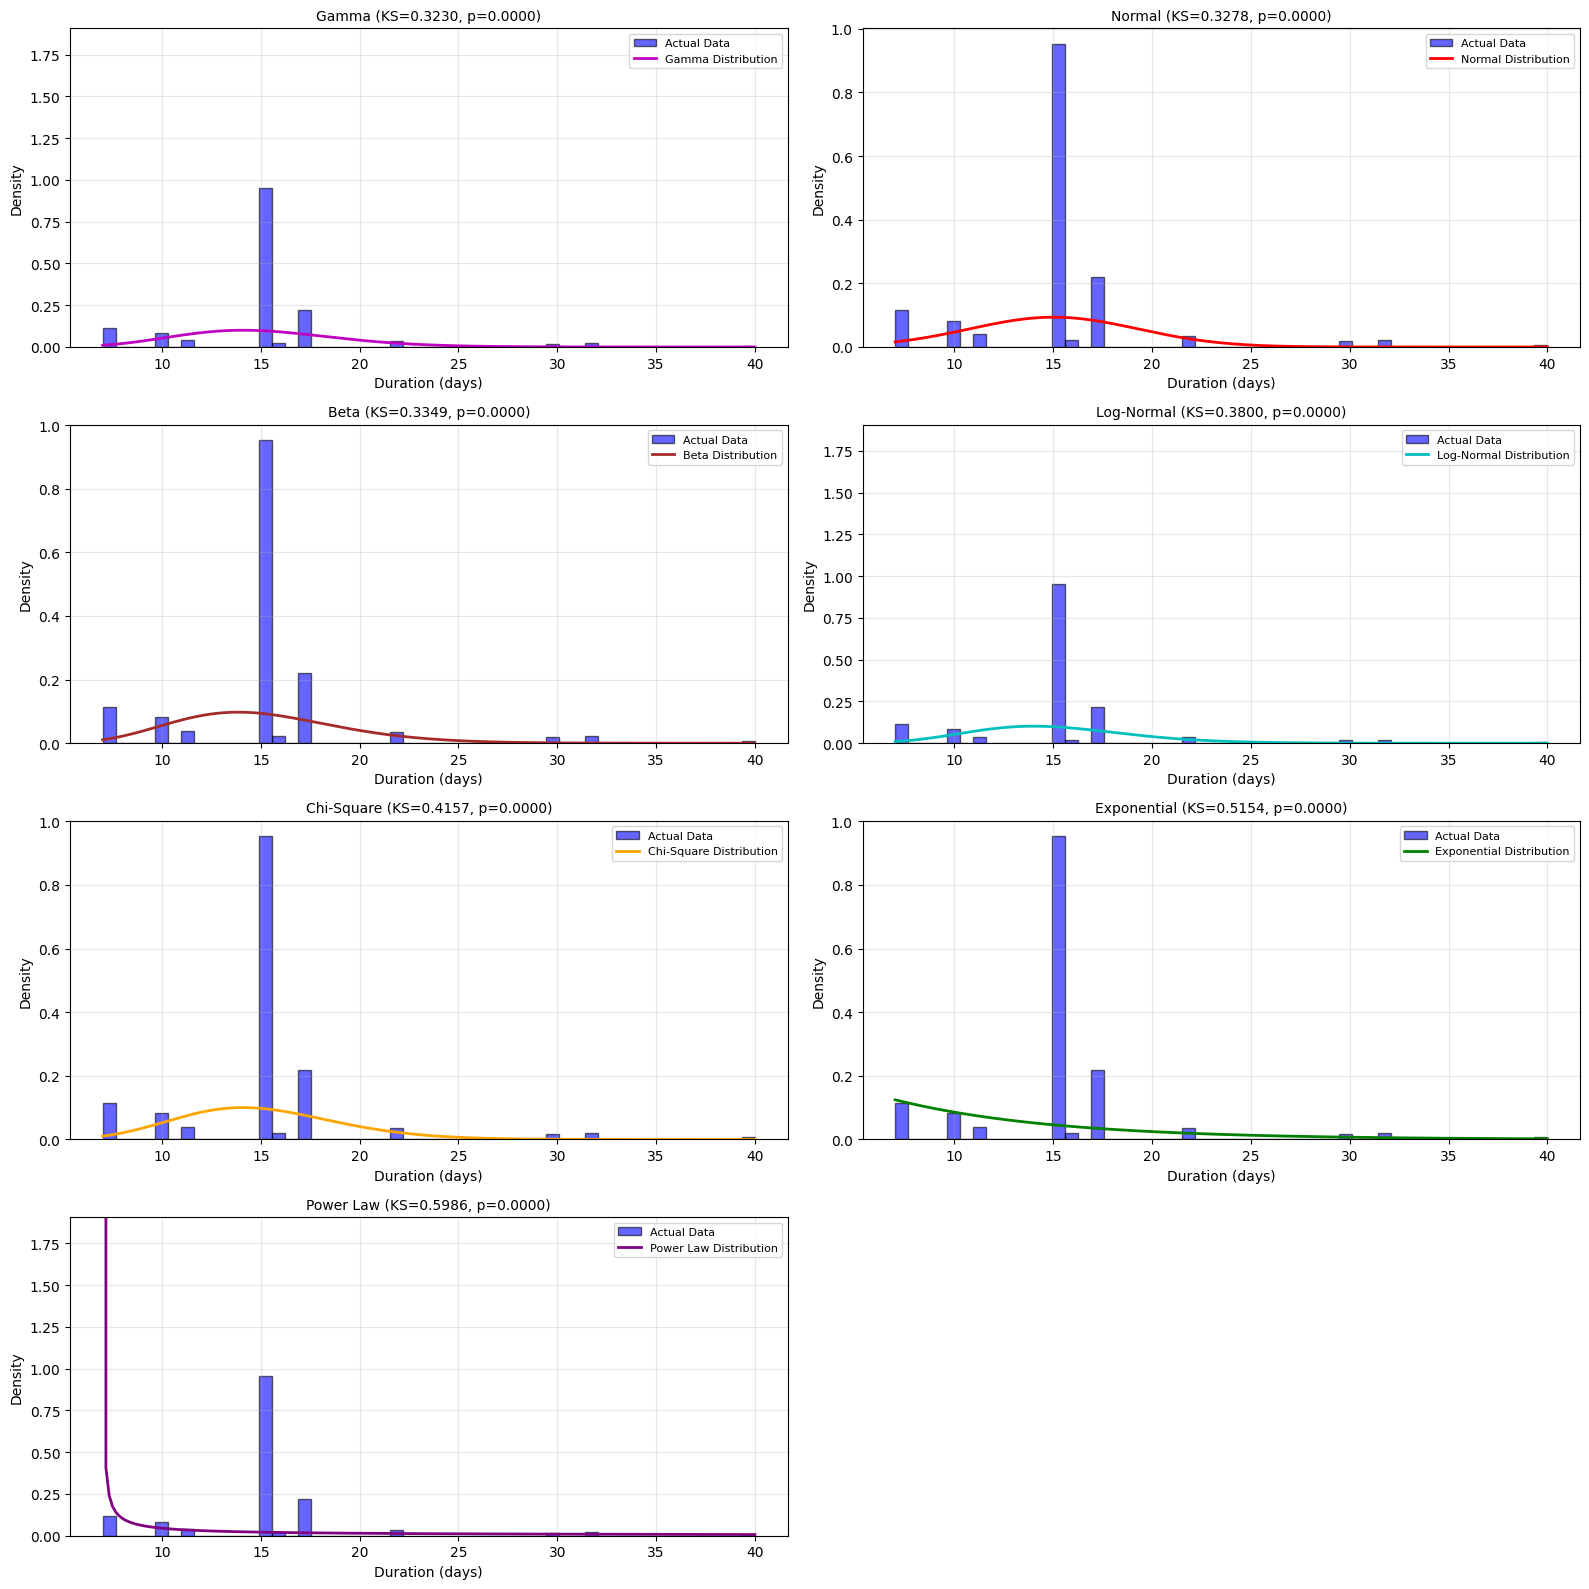


All Distribution Rankings (sorted by best fit):
1. Gamma: KS=0.323040, p-value=0.000000
2. Normal: KS=0.327791, p-value=0.000000
3. Beta: KS=0.334917, p-value=0.000000
4. Log-Normal: KS=0.380048, p-value=0.000000
5. Chi-Square: KS=0.415677, p-value=0.000000
6. Exponential: KS=0.515439, p-value=0.000000
7. Power Law: KS=0.598575, p-value=0.000000


In [230]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with subplots for all distributions
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Get all distributions
all_dists = results_df

for idx, (dist_name, _) in enumerate(all_dists.iterrows()):
    ax = axes[idx]
    
    # Plot histogram of actual data
    n, bins, patches = ax.hist(duration_data, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black', label='Actual Data')
    
    # Get the maximum histogram value for y-axis scaling
    max_hist = np.max(n)
    
    # Generate x range for distribution
    x_range = np.linspace(duration_data.min(), duration_data.max(), 200)
    
    # Plot distribution line
    if dist_name == 'Normal':
        mu_norm, sigma_norm = norm.fit(duration_data)
        pdf_vals = norm.pdf(x_range, mu_norm, sigma_norm)
        ax.plot(x_range, pdf_vals, 'r-', linewidth=2, label='Normal Distribution')
    
    elif dist_name == 'Exponential':
        exp_fit = expon.fit(duration_data)
        pdf_vals = expon.pdf(x_range, loc=exp_fit[0], scale=exp_fit[1])
        ax.plot(x_range, pdf_vals, 'g-', linewidth=2, label='Exponential Distribution')
    
    elif dist_name == 'Gamma':
        gamma_shape, gamma_loc, gamma_scale = gamma.fit(duration_data)
        pdf_vals = gamma.pdf(x_range, gamma_shape, loc=gamma_loc, scale=gamma_scale)
        ax.plot(x_range, pdf_vals, 'm-', linewidth=2, label='Gamma Distribution')
        # Set reasonable y-limit for gamma
        ax.set_ylim(0, max_hist * 2)
    
    elif dist_name == 'Log-Normal':
        lognorm_shape, lognorm_loc, lognorm_scale = lognorm.fit(duration_data)
        pdf_vals = lognorm.pdf(x_range, lognorm_shape, loc=lognorm_loc, scale=lognorm_scale)
        ax.plot(x_range, pdf_vals, 'c-', linewidth=2, label='Log-Normal Distribution')
        # Set reasonable y-limit for log-normal
        ax.set_ylim(0, max_hist * 2)
    
    elif dist_name == 'Chi-Square':
        chi2_df, chi2_loc, chi2_scale = chi2.fit(duration_data)
        pdf_vals = chi2.pdf(x_range, chi2_df, loc=chi2_loc, scale=chi2_scale)
        ax.plot(x_range, pdf_vals, 'orange', linewidth=2, label='Chi-Square Distribution')
    
    elif dist_name == 'Power Law':
        powerlaw_shape, powerlaw_loc, powerlaw_scale = powerlaw.fit(duration_data)
        pdf_vals = powerlaw.pdf(x_range, powerlaw_shape, loc=powerlaw_loc, scale=powerlaw_scale)
        ax.plot(x_range, pdf_vals, 'purple', linewidth=2, label='Power Law Distribution')
        # Set reasonable y-limit for power law
        ax.set_ylim(0, max_hist * 2)
    
    elif dist_name == 'Beta':
        beta_a, beta_b, beta_loc, beta_scale = beta.fit(duration_data)
        pdf_vals = beta.pdf(x_range, beta_a, beta_b, loc=beta_loc, scale=beta_scale)
        ax.plot(x_range, pdf_vals, 'brown', linewidth=2, label='Beta Distribution')
    
    ax.set_title(f'{dist_name} (KS={results_df.loc[dist_name, "ks"]:.4f}, p={results_df.loc[dist_name, "p_value"]:.4f})', fontsize=10)
    ax.set_xlabel('Duration (days)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide the last unused subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

print("\nAll Distribution Rankings (sorted by best fit):")
for idx, (dist_name, row) in enumerate(all_dists.iterrows(), 1):
    print(f"{idx}. {dist_name}: KS={row['ks']:.6f}, p-value={row['p_value']:.6f}")

In [231]:
# Export to specific path
file_path = r"../../data/processed/library_borrowings.csv"  # Windows

df.to_csv(file_path, index=False, encoding='utf-8')
print(f"Data exported to: {file_path}")

Data exported to: ../../data/processed/library_borrowings.csv
